In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/credit_clean.csv')
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150

import os
os.makedirs('../charts', exist_ok=True)

Loaded: 307,507 rows, 172 columns


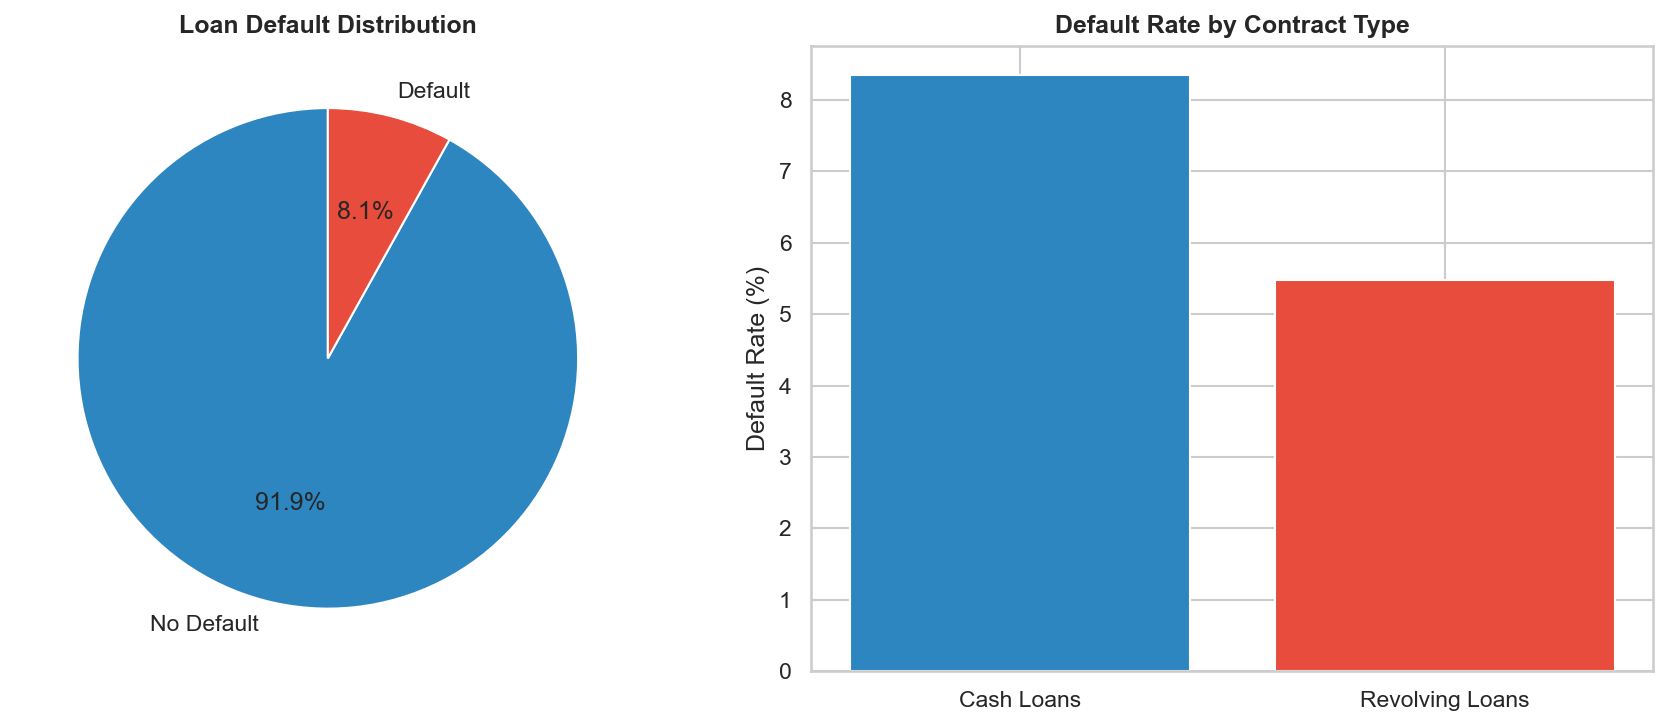

Chart 1 saved


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors = ['#2E86C1', '#E74C3C']
ax1.pie(df['TARGET'].value_counts(),
        labels=['No Default', 'Default'],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90)
ax1.set_title('Loan Default Distribution', fontweight='bold')

# Bar chart by contract type
contract_default = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean() * 100
ax2.bar(['Cash Loans', 'Revolving Loans'],
        contract_default.values,
        color=colors)
ax2.set_title('Default Rate by Contract Type', fontweight='bold')
ax2.set_ylabel('Default Rate (%)')

plt.tight_layout()
plt.savefig('../charts/01_default_distribution.png', dpi=150)
plt.show()
print("Chart 1 saved")

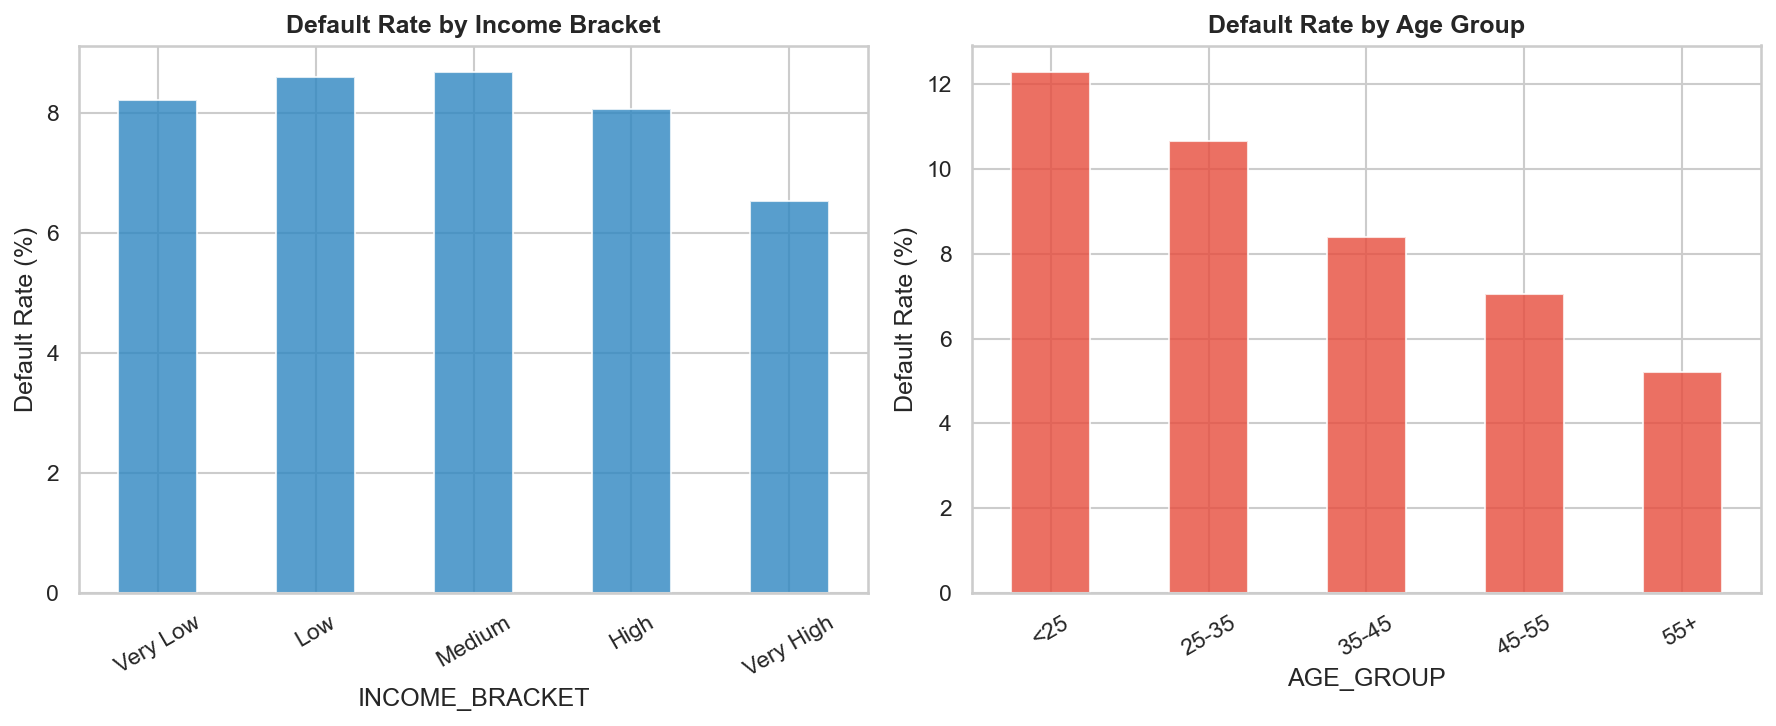

Chart 2 saved


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Income vs default
df['INCOME_BRACKET'] = pd.qcut(df['AMT_INCOME_TOTAL'],
                                q=5,
                                labels=['Very Low', 'Low', 'Medium',
                                        'High', 'Very High'])
income_default = df.groupby('INCOME_BRACKET', observed=True)['TARGET'].mean() * 100
income_default.plot(kind='bar', ax=ax1, color='#2E86C1', alpha=0.8)
ax1.set_title('Default Rate by Income Bracket', fontweight='bold')
ax1.set_ylabel('Default Rate (%)')
ax1.tick_params(axis='x', rotation=30)

# Age vs default
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'],
                          bins=[0, 25, 35, 45, 55, 100],
                          labels=['<25', '25-35', '35-45', '45-55', '55+'])
age_default = df.groupby('AGE_GROUP', observed=True)['TARGET'].mean() * 100
age_default.plot(kind='bar', ax=ax2, color='#E74C3C', alpha=0.8)
ax2.set_title('Default Rate by Age Group', fontweight='bold')
ax2.set_ylabel('Default Rate (%)')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../charts/02_income_age_default.png', dpi=150)
plt.show()
print("Chart 2 saved")

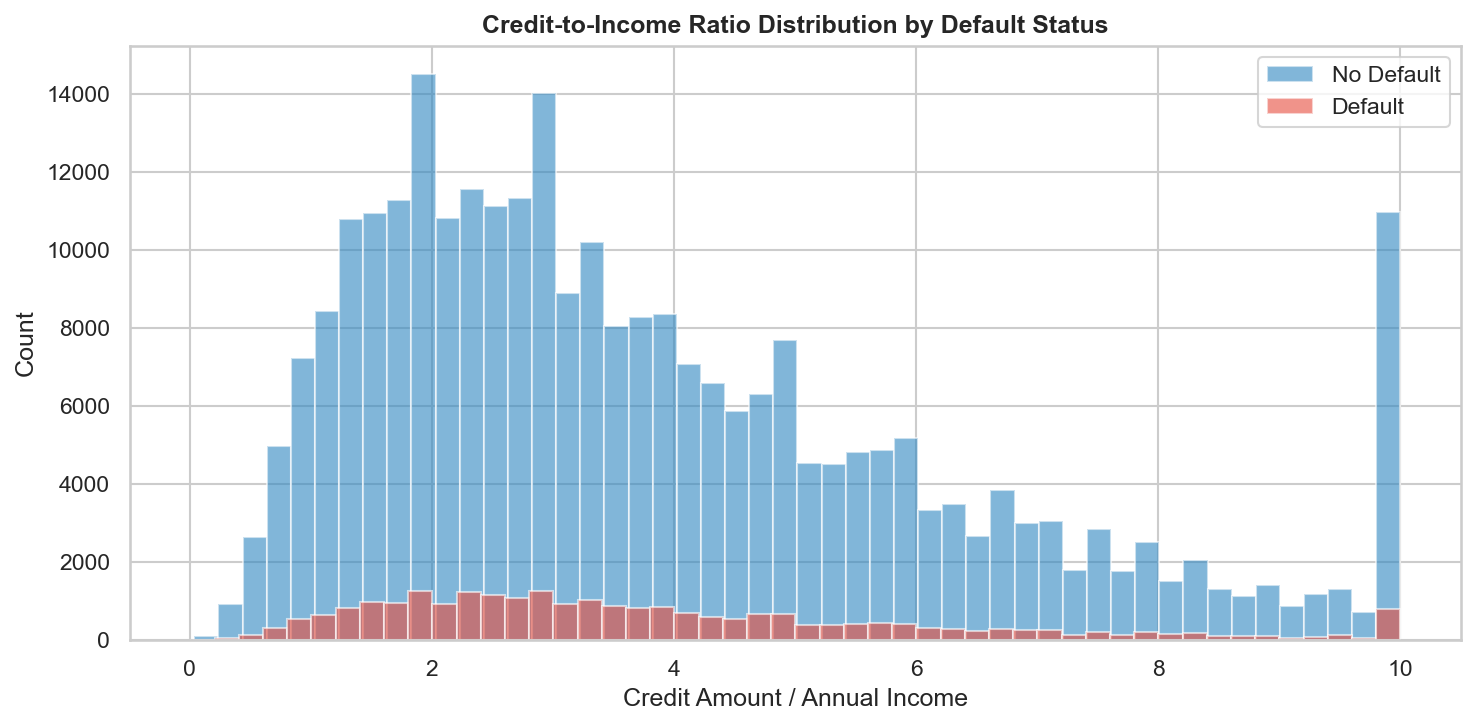

Chart 3 saved


In [4]:
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

fig, ax = plt.subplots(figsize=(10, 5))
df[df['TARGET'] == 0]['CREDIT_INCOME_RATIO'].clip(0, 10).plot(
    kind='hist', bins=50, alpha=0.6, color='#2E86C1',
    label='No Default', ax=ax)
df[df['TARGET'] == 1]['CREDIT_INCOME_RATIO'].clip(0, 10).plot(
    kind='hist', bins=50, alpha=0.6, color='#E74C3C',
    label='Default', ax=ax)
ax.set_title('Credit-to-Income Ratio Distribution by Default Status',
             fontweight='bold')
ax.set_xlabel('Credit Amount / Annual Income')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/03_credit_income_ratio.png', dpi=150)
plt.show()
print("Chart 3 saved")

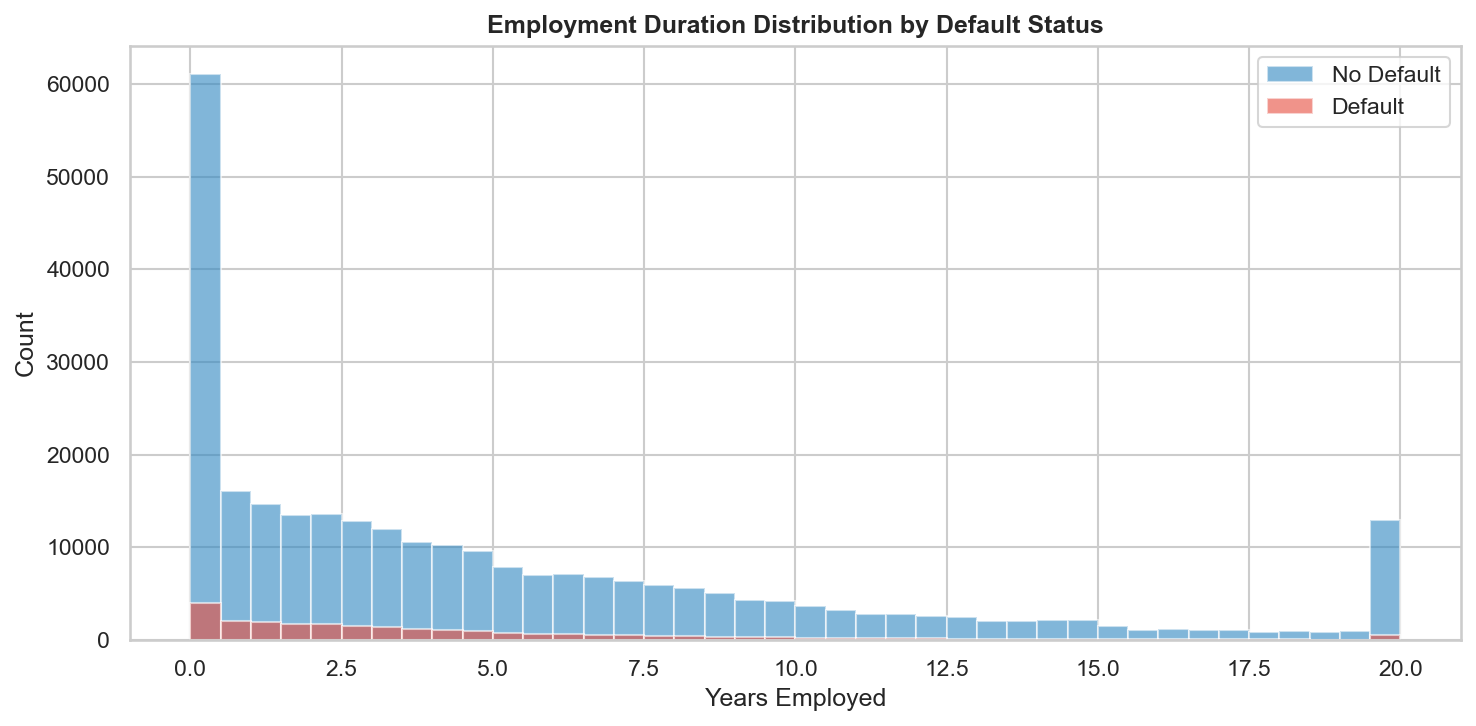

Chart 4 saved


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

df[df['TARGET'] == 0]['EMPLOYMENT_YEARS'].clip(0, 20).plot(
    kind='hist', bins=40, alpha=0.6, color='#2E86C1',
    label='No Default', ax=ax)
df[df['TARGET'] == 1]['EMPLOYMENT_YEARS'].clip(0, 20).plot(
    kind='hist', bins=40, alpha=0.6, color='#E74C3C',
    label='Default', ax=ax)
ax.set_title('Employment Duration Distribution by Default Status',
             fontweight='bold')
ax.set_xlabel('Years Employed')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/04_employment_default.png', dpi=150)
plt.show()
print("Chart 4 saved")

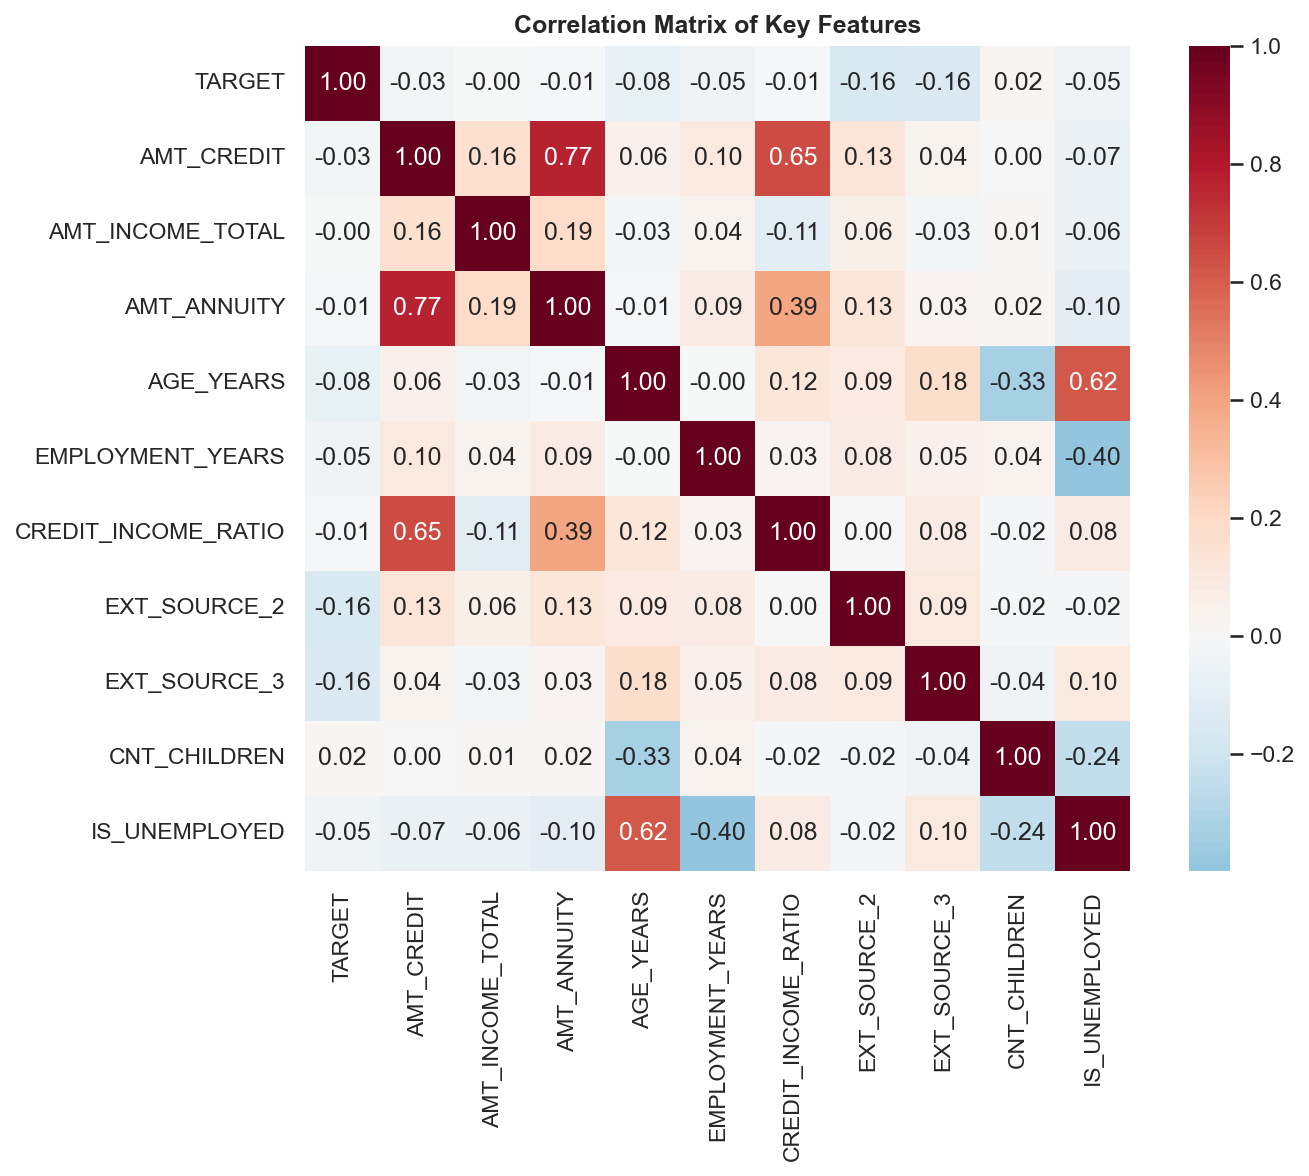

Chart 5 saved


In [6]:
top_features = ['TARGET', 'AMT_CREDIT', 'AMT_INCOME_TOTAL',
                'AMT_ANNUITY', 'AGE_YEARS', 'EMPLOYMENT_YEARS',
                'CREDIT_INCOME_RATIO', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
                'CNT_CHILDREN', 'IS_UNEMPLOYED']

corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            ax=ax, square=True)
ax.set_title('Correlation Matrix of Key Features', fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/05_correlation_heatmap.png', dpi=150)
plt.show()
print("Chart 5 saved")